# Height Prediction Training Inspector

Inspect training data, model predictions, and error maps for the
building height regression head.

Auto-detects whether the saved checkpoint is **v3** (iterative refinement +
mask head, 5-channel input) or **v2** (single forward pass, 3-channel input)
and renders the appropriate visualisations.

**Sections:**
1. Tile inspection — RGB/height pairs, height distributions
2. Training history — loss curves
3. Model evaluation — MAE/RMSE on building pixels (v3 gates by mask)
4. Per-tile predictions — RGB | GT | (Mask) | Pred | Error

**Prerequisites:**
```bash
pip install torch torchvision matplotlib osmnx rasterio shapely

# Standard-resolution tiles (256 px @ 2 m/px):
python -m tools.ml.collect_osm_tiles --cities Berlin Vienna --tiles-per-city 50

# High-resolution tiles (512 px @ 1 m/px) for v3:
python -m tools.ml.collect_osm_tiles --cities Berlin Vienna Paris --tiles-per-city 25 \
    --tile-size 512 --target-res-m 1.0 --tile-dir cache/height_tiles_hr

# Train v3:
python -c "from tools.ml.train import train_v3, TrainConfig; \
    train_v3(tile_dir='cache/height_tiles_osm', output_model='models/roofnet_height_v3.pt', \
             config=TrainConfig(task='height', epochs=8, batch_size=4, lr=1e-3, tile_size=256))"
```

In [14]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

from tools.ml.config import DEFAULT_HEIGHT_MODEL, MAX_HEIGHT_M

PROJECT_ROOT = Path('..').resolve()
TILE_DIR = PROJECT_ROOT / 'cache' / 'height_tiles_osm'

# Auto-detect best checkpoint to inspect (v3 preferred, fall back to v1)
CANDIDATE_PATHS = [
    PROJECT_ROOT / DEFAULT_HEIGHT_MODEL,                  # config default
    PROJECT_ROOT / 'models' / 'roofnet_v3.pt',            # current train output
    PROJECT_ROOT / 'models' / 'roofnet_height_v3.pt',
    PROJECT_ROOT / 'models' / 'roofnet_height_v1.pt',     # legacy v2 baseline
]
MODEL_PATH = next((p for p in CANDIDATE_PATHS if p.exists()), CANDIDATE_PATHS[0])

# Detect arch from checkpoint state_dict keys
def _detect_arch(ckpt_path):
    if not ckpt_path.exists():
        return None
    import torch
    state = torch.load(str(ckpt_path), map_location='cpu', weights_only=False)
    sd = state.get('model_state_dict', state)
    keys = list(sd.keys()) if isinstance(sd, dict) else []
    if any(k.startswith('mask_head.') for k in keys):
        return 'v3'
    if any(k.startswith('backbone.') for k in keys):
        return 'v2'
    return None

ARCH = _detect_arch(MODEL_PATH)
print(f'Tile dir : {TILE_DIR}')
print(f'Model    : {MODEL_PATH}')
print(f'Tiles    : {TILE_DIR.exists()}, count={len(list(TILE_DIR.glob("*.npz")))}')
print(f'Model exists: {MODEL_PATH.exists()}, arch={ARCH}')

Tile dir : C:\Users\eac84\OneDrive\Documents\Projects\3D Maps\Code\strm2stl\cache\height_tiles_osm
Model    : C:\Users\eac84\OneDrive\Documents\Projects\3D Maps\Code\strm2stl\models\roofnet_height_v3.pt
Tiles    : True, count=280
Model exists: True, arch=v2


## 1. Tile Inspection

Total tiles: 280


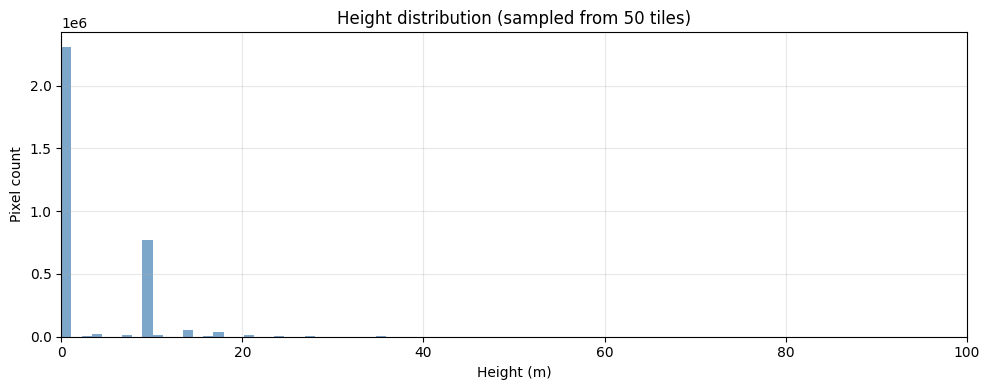

Height stats: min=0.0m, max=112.0m, mean=3.4m, median=0.0m


In [15]:
tile_paths = sorted(TILE_DIR.glob('*.npz')) if TILE_DIR.exists() else []
print(f'Total tiles: {len(tile_paths)}')

if tile_paths:
    # Show height distribution across all tiles
    all_heights = []
    for tp in tile_paths[:50]:  # sample first 50
        data = np.load(tp)
        h = data['height'].ravel()
        h = h[~np.isnan(h)]
        all_heights.extend(h.tolist())
    
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.hist(all_heights, bins=100, color='steelblue', alpha=0.7, edgecolor='none')
    ax.set_xlabel('Height (m)')
    ax.set_ylabel('Pixel count')
    ax.set_title(f'Height distribution (sampled from {min(50, len(tile_paths))} tiles)')
    ax.set_xlim(0, min(100, max(all_heights) if all_heights else 50))
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    print(f'Height stats: min={min(all_heights):.1f}m, max={max(all_heights):.1f}m, '
          f'mean={np.mean(all_heights):.1f}m, median={np.median(all_heights):.1f}m')

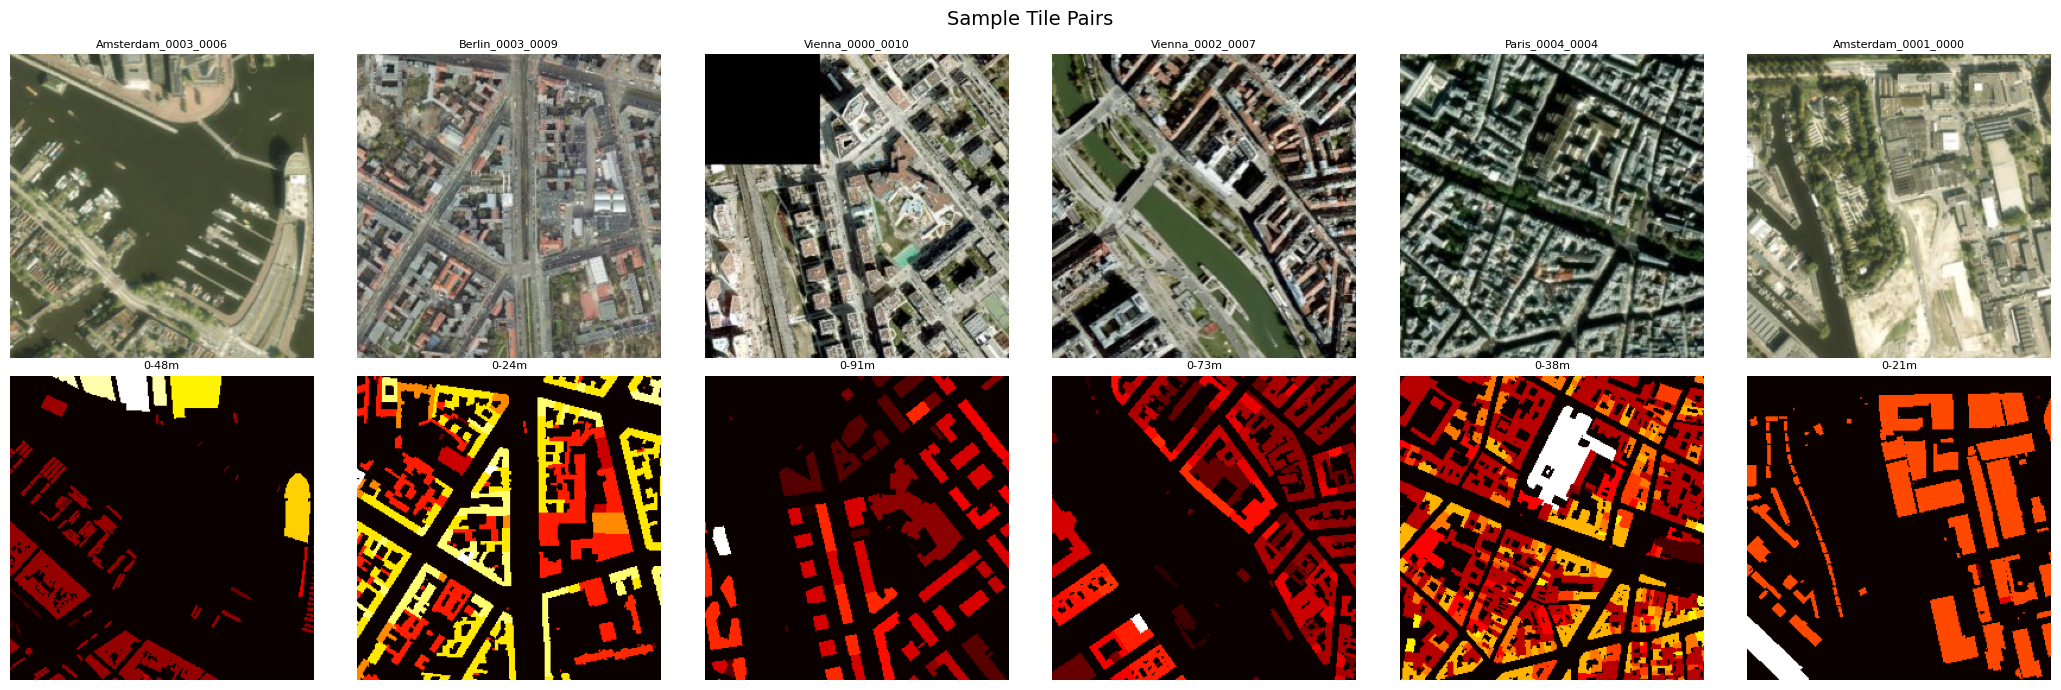

In [16]:
# Show sample tile pairs (RGB + height)
if tile_paths:
    n_show = min(6, len(tile_paths))
    fig, axes = plt.subplots(2, n_show, figsize=(3.5 * n_show, 7))
    
    np.random.seed(42)
    indices = np.random.choice(len(tile_paths), n_show, replace=False)
    
    for col, idx in enumerate(indices):
        data = np.load(tile_paths[idx])
        rgb = data['rgb']      # (3, H, W)
        height = data['height'] # (1, H, W)
        
        ax_rgb = axes[0, col]
        rgb_disp = rgb.transpose(1, 2, 0)  # (H, W, 3)
        if rgb_disp.max() <= 1.0:
            rgb_disp = np.clip(rgb_disp, 0, 1)
        else:
            rgb_disp = np.clip(rgb_disp / 255.0, 0, 1)
        ax_rgb.imshow(rgb_disp)
        ax_rgb.set_title(tile_paths[idx].stem, fontsize=8)
        ax_rgb.axis('off')
        
        ax_h = axes[1, col]
        im = ax_h.imshow(height[0], cmap='hot', vmin=0)
        ax_h.set_title(f'{height[0].min():.0f}-{height[0].max():.0f}m', fontsize=8)
        ax_h.axis('off')
    
    axes[0, 0].set_ylabel('RGB', fontsize=12)
    axes[1, 0].set_ylabel('Height', fontsize=12)
    plt.suptitle('Sample Tile Pairs', fontsize=14)
    plt.tight_layout()
    plt.show()
else:
    print('No tiles to display')

## 2. Training History

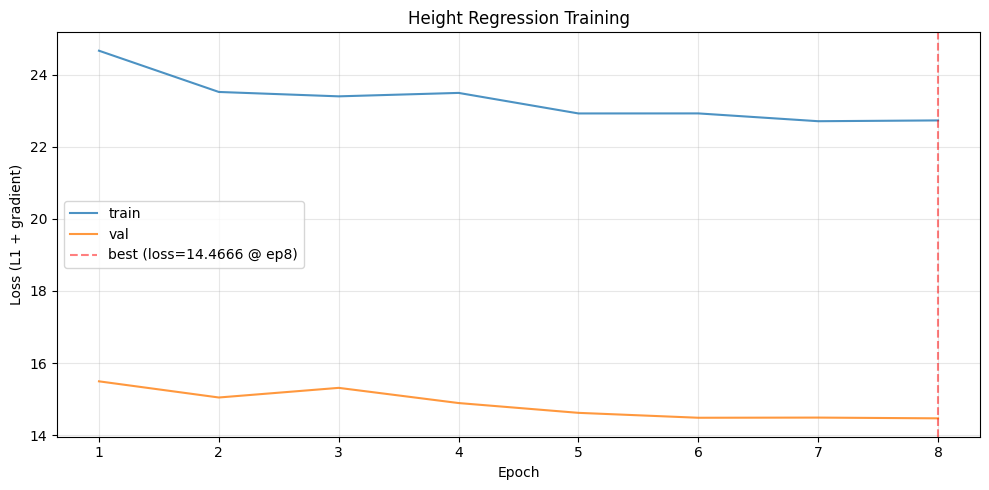

In [11]:
import json

history_path = MODEL_PATH.parent / (MODEL_PATH.stem + '_history.json')
if history_path.exists():
    with open(history_path) as f:
        hist_data = json.load(f)
    
    h = hist_data['history']
    epochs = [e['epoch'] for e in h]
    
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.plot(epochs, [e['train_loss'] for e in h], label='train', alpha=0.8)
    ax.plot(epochs, [e['val_loss'] for e in h], label='val', alpha=0.8)
    
    best_epoch = hist_data.get('best_epoch', 0)
    best_loss = hist_data.get('best_val_loss', 0)
    if best_epoch:
        ax.axvline(best_epoch, color='red', linestyle='--', alpha=0.5,
                   label=f'best (loss={best_loss:.4f} @ ep{best_epoch})')
    
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss (L1 + gradient)')
    ax.set_title('Height Regression Training')
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print(f'No history at {history_path}')

## 3. Model Evaluation

Arch: v2
All-pixel  MAE = 452211.84 m   RMSE = 737882.69 m
Bldg-pixel MAE = 436938.09 m   RMSE = 709436.38 m
Val tiles: 42


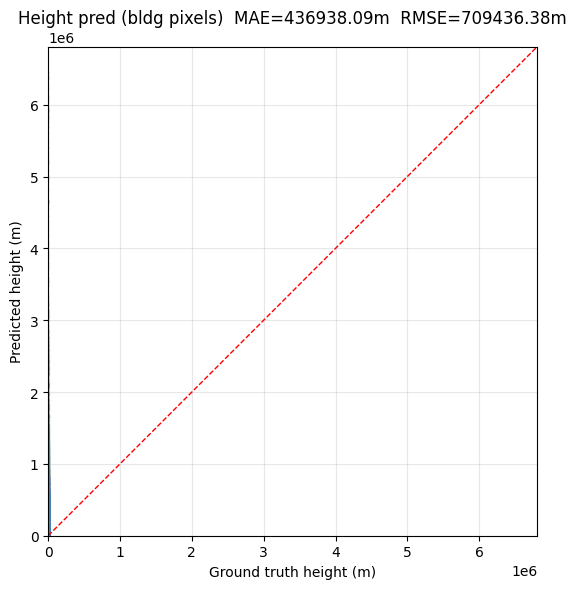

In [17]:
if MODEL_PATH.exists() and tile_paths:
    import torch
    from tools.ml.models import build_model
    from tools.ml.data import HeightTileDataset, make_height_loaders

    model = build_model(arch=ARCH or 'v2', task='height',
                        checkpoint=str(MODEL_PATH), device='cpu')
    model.eval()

    _, val_loader, split = make_height_loaders(
        tile_paths, tile_size=126, batch_size=4,
    )

    # Collect predictions on building pixels
    all_preds, all_targets = [], []
    bldg_preds, bldg_targets = [], []
    with torch.no_grad():
        for rgb, height in val_loader:
            if ARCH == 'v3':
                mask_logits, height_pred, _ = model(rgb, n_iters=2)
                mask_prob = torch.sigmoid(mask_logits)
                # Gate by mask threshold (matches predict() helper)
                pred = torch.clamp(height_pred, min=0.0) * (mask_prob > 0.3).float()
            else:
                pred, _ = model(rgb)

            p = pred.cpu().numpy()
            t = height.numpy()
            all_preds.append(p.ravel()); all_targets.append(t.ravel())
            bldg = t > 0
            bldg_preds.append(p[bldg]); bldg_targets.append(t[bldg])

    preds_all = np.concatenate(all_preds)
    targets_all = np.concatenate(all_targets)
    preds_bldg = np.concatenate(bldg_preds)
    targets_bldg = np.concatenate(bldg_targets)

    mae_all = np.mean(np.abs(preds_all - targets_all))
    rmse_all = np.sqrt(np.mean((preds_all - targets_all) ** 2))
    mae_bldg = np.mean(np.abs(preds_bldg - targets_bldg)) if len(preds_bldg) else float('nan')
    rmse_bldg = np.sqrt(np.mean((preds_bldg - targets_bldg) ** 2)) if len(preds_bldg) else float('nan')

    print(f'Arch: {ARCH}')
    print(f'All-pixel  MAE = {mae_all:.2f} m   RMSE = {rmse_all:.2f} m')
    print(f'Bldg-pixel MAE = {mae_bldg:.2f} m   RMSE = {rmse_bldg:.2f} m')
    print(f'Val tiles: {split["n_val"]}')

    # Scatter on building pixels (subsample for plot)
    sub = np.random.choice(len(preds_bldg), min(20000, len(preds_bldg)), replace=False)
    fig, ax = plt.subplots(figsize=(6, 6))
    lim = max(targets_bldg.max(), preds_bldg.max(), 1) * 1.05
    ax.scatter(targets_bldg[sub], preds_bldg[sub], alpha=0.05, s=2, c='steelblue')
    ax.plot([0, lim], [0, lim], 'r--', lw=1)
    ax.set_xlabel('Ground truth height (m)')
    ax.set_ylabel('Predicted height (m)')
    ax.set_title(f'Height pred (bldg pixels)  MAE={mae_bldg:.2f}m  RMSE={rmse_bldg:.2f}m')
    ax.set_xlim(0, lim); ax.set_ylim(0, lim); ax.set_aspect('equal')
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(str(PROJECT_ROOT / 'output' / 'height_scatter.png'), dpi=120, bbox_inches='tight')
    plt.show()
else:
    print('Model or tiles not found')

## 4. Per-Tile Predictions

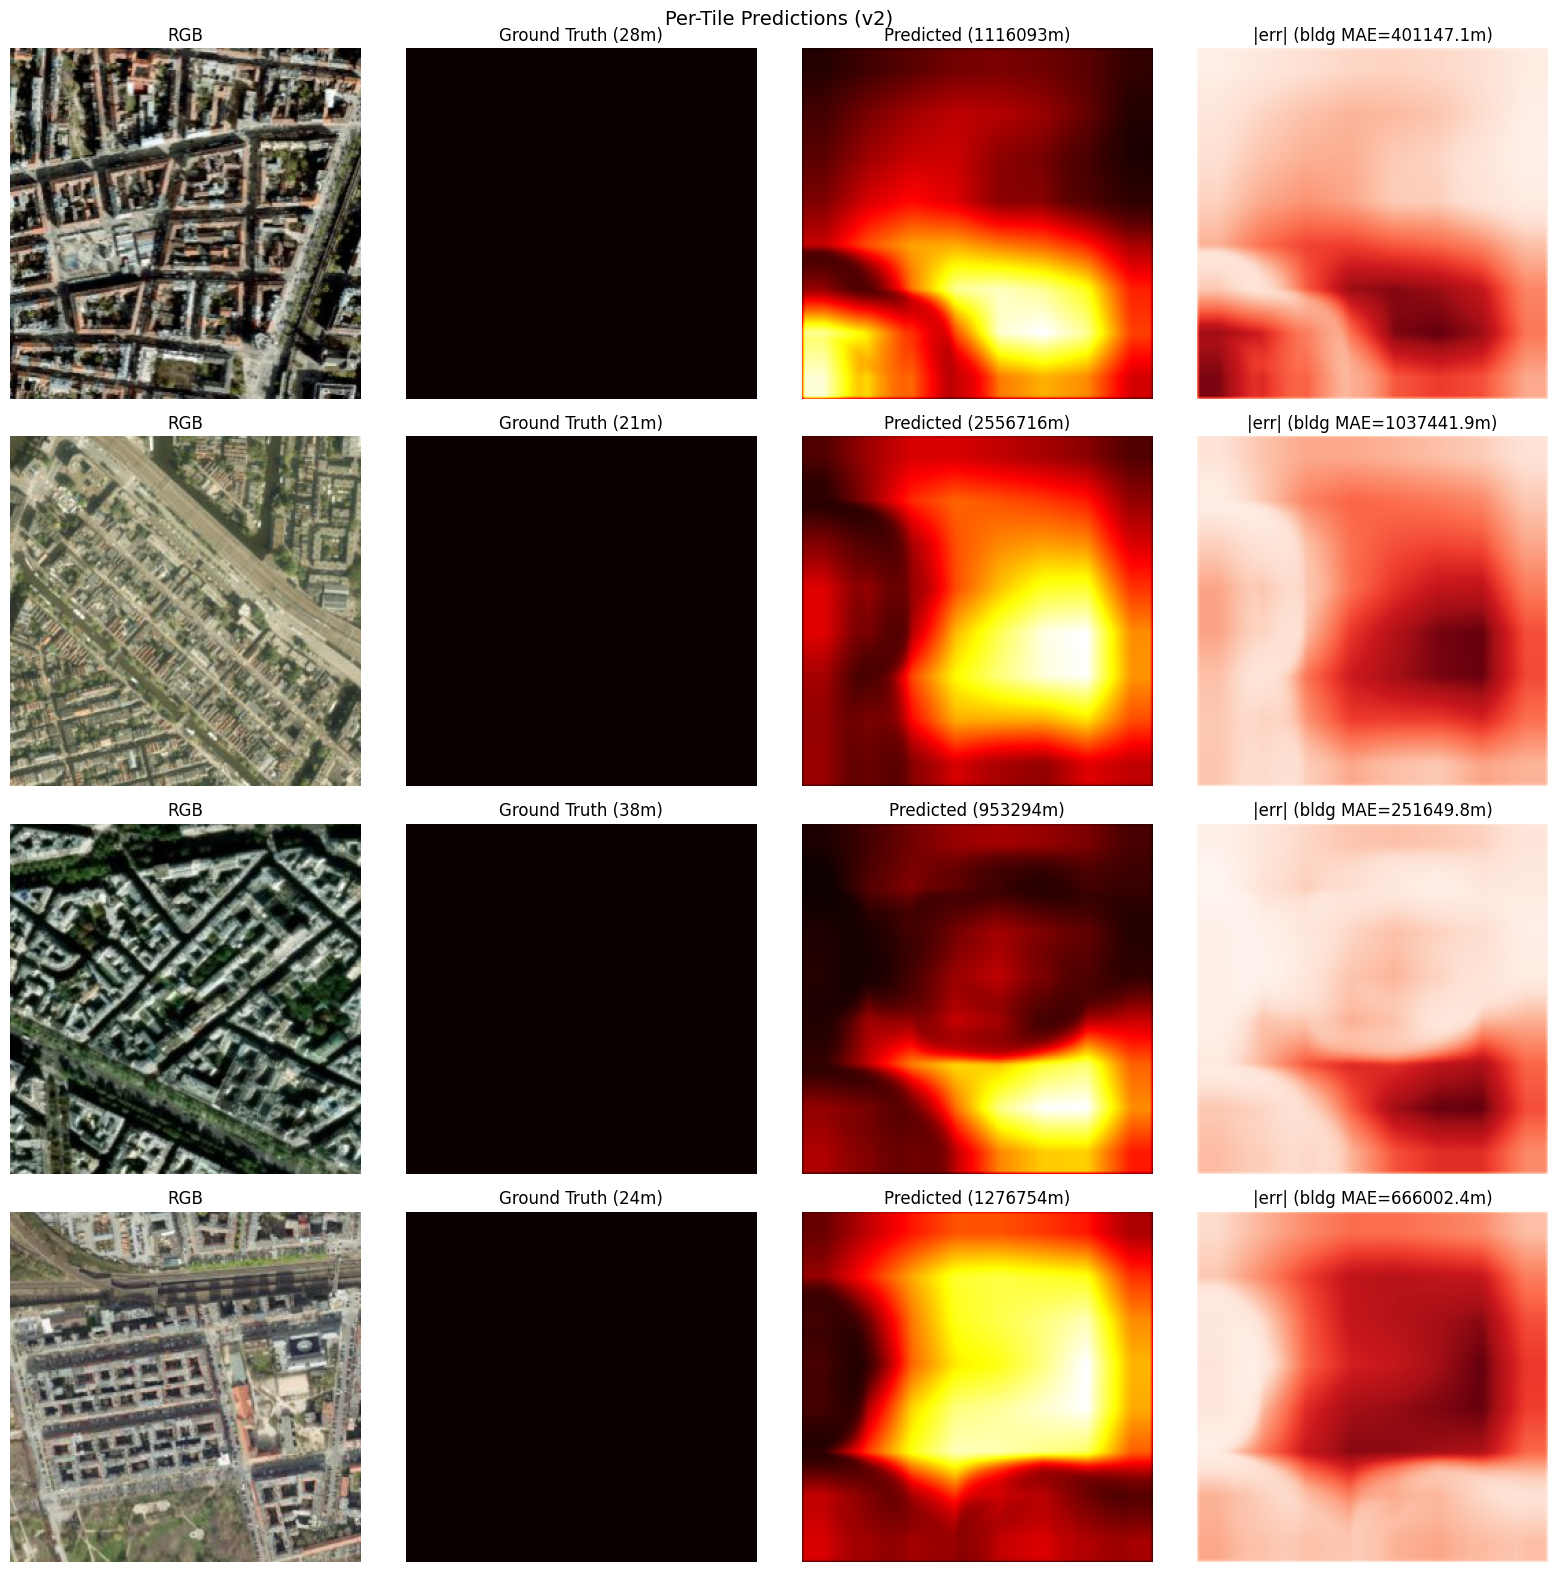

In [18]:
# Side-by-side: RGB | Ground Truth | Prediction | Error Map
if MODEL_PATH.exists() and tile_paths:
    import torch
    from tools.ml.models import build_model
    from tools.ml.data import HeightTileDataset

    model = build_model(arch=ARCH or 'v2', task='height',
                        checkpoint=str(MODEL_PATH), device='cpu')
    model.eval()

    ds = HeightTileDataset(tile_paths)
    n_show = min(4, len(ds))
    np.random.seed(0)
    indices = np.random.choice(len(ds), n_show, replace=False)

    cols = 5 if ARCH == 'v3' else 4
    fig, axes = plt.subplots(n_show, cols, figsize=(4 * cols, 4 * n_show))
    if n_show == 1:
        axes = axes[np.newaxis, :]

    for row, idx in enumerate(indices):
        rgb_t, height_t = ds[idx]

        with torch.no_grad():
            if ARCH == 'v3':
                mask_logits, height_pred, _ = model(rgb_t.unsqueeze(0), n_iters=2)
                mask_prob = torch.sigmoid(mask_logits)[0, 0].numpy()
                pred_raw = torch.clamp(height_pred, min=0.0)[0, 0].numpy()
                pred = pred_raw * (mask_prob > 0.3)
            else:
                pred_t, _ = model(rgb_t.unsqueeze(0))
                pred = pred_t[0, 0].numpy()
                mask_prob = None

        rgb_np = np.clip(rgb_t.numpy().transpose(1, 2, 0), 0, 1)
        gt = height_t.numpy()[0]
        error = np.abs(pred - gt)
        vmax = max(gt.max(), pred.max(), 1)

        axes[row, 0].imshow(rgb_np); axes[row, 0].set_title('RGB'); axes[row, 0].axis('off')
        axes[row, 1].imshow(gt, cmap='hot', vmin=0, vmax=vmax)
        axes[row, 1].set_title(f'Ground Truth ({gt.max():.0f}m)'); axes[row, 1].axis('off')

        col = 2
        if ARCH == 'v3':
            axes[row, col].imshow(mask_prob, cmap='Blues', vmin=0, vmax=1)
            axes[row, col].set_title('Mask (sigmoid)'); axes[row, col].axis('off')
            col += 1

        axes[row, col].imshow(pred, cmap='hot', vmin=0, vmax=vmax)
        axes[row, col].set_title(f'Predicted ({pred.max():.0f}m)'); axes[row, col].axis('off')
        col += 1

        bldg = gt > 0
        bldg_mae = error[bldg].mean() if bldg.any() else 0.0
        axes[row, col].imshow(error, cmap='Reds', vmin=0)
        axes[row, col].set_title(f'|err| (bldg MAE={bldg_mae:.1f}m)'); axes[row, col].axis('off')

    plt.suptitle(f'Per-Tile Predictions ({ARCH})', fontsize=14)
    plt.tight_layout()
    plt.savefig(str(PROJECT_ROOT / 'output' / 'height_tile_predictions.png'), dpi=120, bbox_inches='tight')
    plt.show()
else:
    print('Model or tiles not found')

## 5. Quick Train (optional)

Run a quick height training from this notebook.

In [ ]:
# Uncomment to train v3 (RoofNetV3 with iterative refinement + mask head):

# from tools.ml.train import train_v3, TrainConfig
# 
# cfg = TrainConfig(
#     task='height',
#     epochs=8,
#     batch_size=4,
#     lr=1e-3,
#     patience=10,
#     tile_size=256,    # use 512 with high-res tiles in cache/height_tiles_hr
#     device='cpu',
# )
# 
# result = train_v3(
#     tile_dir='cache/height_tiles_osm',
#     output_model='models/roofnet_height_v3.pt',
#     config=cfg,
#     n_iters=2,
# )
# print(f'Best val loss: {result["best_val_loss"]:.4f}  epoch {result["best_epoch"]}')